In [12]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings("ignore")

In [13]:
vehicle_data = pd.read_csv('data/auto.csv')
vehicle_data.rename(columns={'horsepower':'hp'}, inplace=True)
vehicle_data.astype({'hp':'int64'})
vehicle_data['hp2'] = vehicle_data['hp'].apply(lambda x: x*x)
vehicle_data


,mpg,cylinders,displacement,hp,weight,acceleration,year,origin,name,hp2
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,16900.0
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,27225.0
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,22500.0
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,22500.0
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,19600.0
...,...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl,7396.0
388,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup,2704.0
389,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage,7056.0
390,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger,6241.0


In [14]:
model = LinearRegression()
model.fit(vehicle_data[['hp']], vehicle_data['mpg'])

LinearRegression()

In [15]:
vehicle_data['predict'] = model.predict(vehicle_data[['hp']])
model.fit(vehicle_data[['hp', 'hp2']], vehicle_data['mpg'])
vehicle_data['predict_2d'] = model.predict(vehicle_data[['hp', 'hp2']])

In [16]:
model.coef_

array([-0.46618963,  0.00123054])

In [17]:
model.intercept_

56.90009970211294

In [24]:
from sklearn.metrics import mean_squared_error
print(f"MSE: {mean_squared_error(vehicle_data['mpg'], vehicle_data['predict_2d'])}")

MSE: 18.98476890761722


In [19]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=vehicle_data['hp'], y = vehicle_data['mpg'], mode = "markers", name = "actual"))
fig.add_trace(go.Scatter(x=vehicle_data['hp'], y = vehicle_data['predict']))
fig.update_layout(font_size = 20)

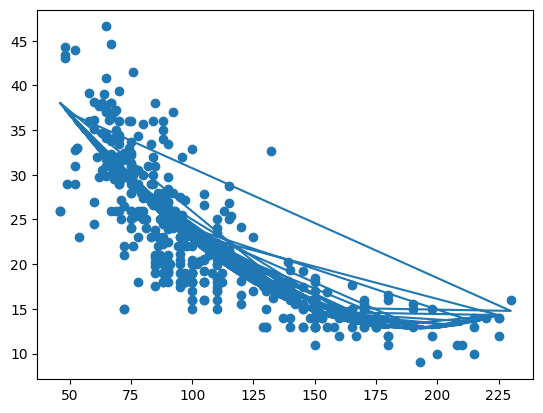

In [20]:
plt.scatter(vehicle_data['hp'], vehicle_data['mpg'])
plt.plot(vehicle_data['hp'], vehicle_data['predict_2d'])

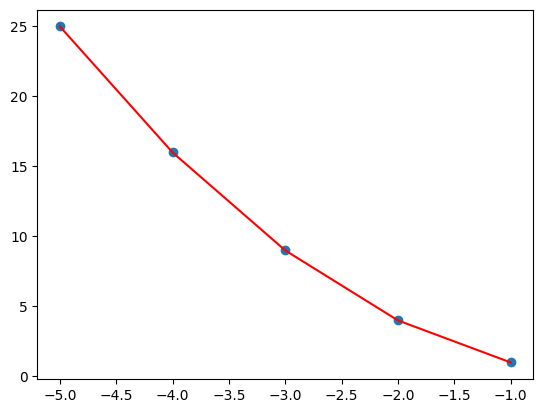

In [21]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Define the data
x = np.array([-1, -2, -3, -4, -5])
y = np.array([1, 4, 9, 16, 25])

# Reshape the data to fit the model
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Transform the data
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

# Fit the model
model = LinearRegression()
model.fit(x_poly, y)

# Predict y values
y_pred = model.predict(x_poly)

# Plot the original data and the polynomial fit
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.show()